# Logistic Regression for Binary Classification

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier

## Data Understanding

In [2]:
df = pd.read_csv('Loan_Predication.csv')

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Check Duplicates

In [5]:

df[df.duplicated()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status


## Data Cleaning and Hanling Missing Values

In [6]:
df.drop("Loan_ID", axis=1, inplace=True)

In [7]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [9]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

## Feature engineering

In [10]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


## Outlier Detection and Handling

In [11]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_Income
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,5403.459283,1621.245798,145.752443,342.410423,0.855049,7024.705081
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339,6458.663872
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,1442.000000
25%,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,4166.000000
50%,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,5416.500000
75%,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,7521.750000
max,3.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,81000.000000


In [12]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income']

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected.")
    return outliers

for col in num_cols:
    detect_outliers(df, col)

ApplicantIncome: 50 outliers detected.
CoapplicantIncome: 18 outliers detected.
LoanAmount: 41 outliers detected.
Loan_Amount_Term: 88 outliers detected.
Total_Income: 50 outliers detected.


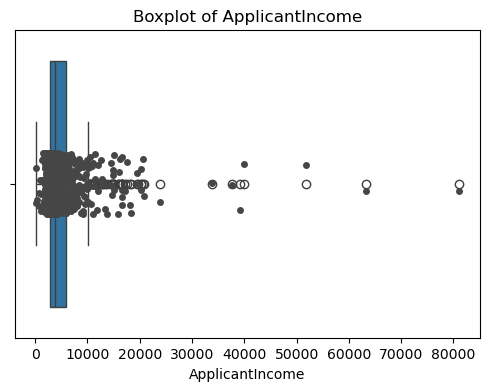

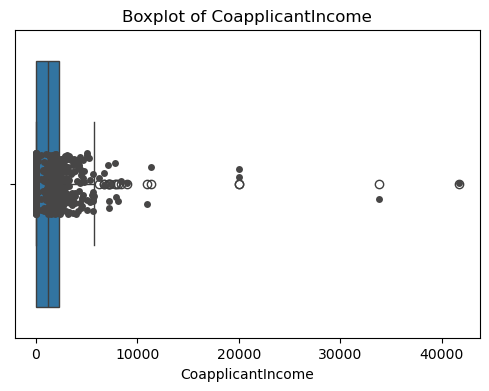

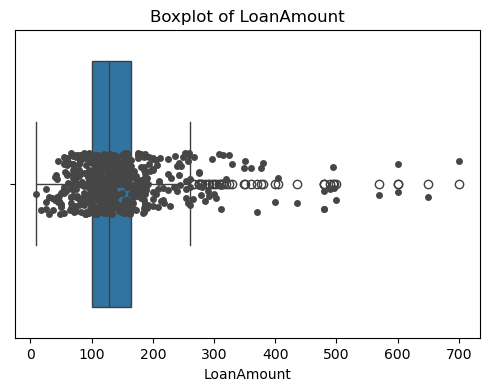

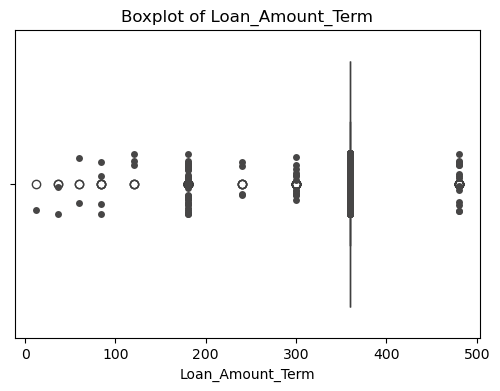

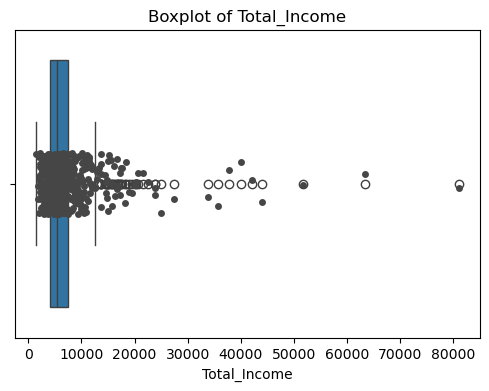

In [13]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=col, data=df)
    sns.stripplot(x=col, data=df, color="#474646")
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
from datasist.structdata import detect_outliers

In [15]:
outliers_indices = detect_outliers(df, 0, num_cols)
len(outliers_indices)

156

In [16]:
for col in num_cols:
    col_median = df[col].median()
    df[col].loc[outliers_indices] = col_median

C:\Users\HP\AppData\Local\Temp\ipykernel_15080\3770332181.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[col].loc[outliers_indices] = col_median
C:\Users\HP\AppData\Local\Temp\ipykernel_15080\3770332181.py:3: SettingWithCopyWarning: 

## Data Encoding

In [17]:
print(df['Gender'].unique())
print(df['Married'].unique())
print(df['Education'].unique())
print(df['Self_Employed'].unique())
print(df['Property_Area'].unique())

['Male' 'Female']
['No' 'Yes']
['Graduate' 'Not Graduate']
['No' 'Yes']
['Urban' 'Rural' 'Semiurban']


In [18]:
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [19]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849.0,0.0,128.0,360.0,1.0,Y,5849.0,True,False,False,False,False,True
1,1,4583.0,1508.0,128.0,360.0,1.0,N,6091.0,True,True,False,False,False,False
2,0,3000.0,0.0,66.0,360.0,1.0,Y,3000.0,True,True,False,True,False,True
3,0,2583.0,2358.0,120.0,360.0,1.0,Y,4941.0,True,True,True,False,False,True
4,0,6000.0,0.0,141.0,360.0,1.0,Y,6000.0,True,False,False,False,False,True


In [20]:
str_cols = ['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
for col in str_cols:
    df[col] = df[col].astype(int)

In [21]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849.0,0.0,128.0,360.0,1.0,Y,5849.0,1,0,0,0,0,1
1,1,4583.0,1508.0,128.0,360.0,1.0,N,6091.0,1,1,0,0,0,0
2,0,3000.0,0.0,66.0,360.0,1.0,Y,3000.0,1,1,0,1,0,1
3,0,2583.0,2358.0,120.0,360.0,1.0,Y,4941.0,1,1,1,0,0,1
4,0,6000.0,0.0,141.0,360.0,1.0,Y,6000.0,1,0,0,0,0,1


In [22]:
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

## Model Training

We prepare the dataset for modeling by selecting relevant features and splitting the data into training and testing sets.

In [23]:
x = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)

In [24]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

We train different models such as:

- Logistic Regression L2 (regular).
- Logistic Regression L1.
- Logistic Regression with GridSearchCV.
- Decision Tree.
- Decision Tree with GridSearchCV.

to predict Loan Status.

### Logistic Regression L2 (regular).

In [25]:
lr_l2 = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)
lr_l2.fit(x_train, y_train)
y_pred_l2 = lr_l2.predict(x_test)

train_acc_l2 = accuracy_score(y_train, lr_l2.predict(x_train))
test_acc_l2 = accuracy_score(y_test, lr_l2.predict(x_test))
auc_l2 = roc_auc_score(y_test, lr_l2.predict_proba(x_test)[:, 1])

print("LR L2 - Test Accuracy:", accuracy_score(y_test, y_pred_l2))
print(confusion_matrix(y_test, y_pred_l2))
print(classification_report(y_test, y_pred_l2))

LR L2 - Test Accuracy: 0.8486486486486486
[[ 32  26]
 [  2 125]]
              precision    recall  f1-score   support

           0       0.94      0.55      0.70        58
           1       0.83      0.98      0.90       127

    accuracy                           0.85       185
   macro avg       0.88      0.77      0.80       185
weighted avg       0.86      0.85      0.84       185



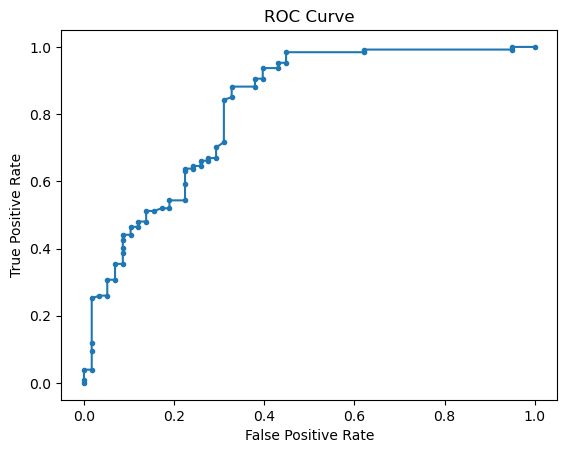

AUC Score: 0.82


In [26]:
y_prob = lr_l2.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.2f}")

### Logistic Regression L1.

In [34]:
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
lr_l1.fit(x_train, y_train)
y_pred_l1 = lr_l1.predict(x_test)

train_acc_l1 = accuracy_score(y_train, lr_l1.predict(x_train))
test_acc_l1 = accuracy_score(y_test, lr_l1.predict(x_test))
auc_l1 = roc_auc_score(y_test, lr_l1.predict_proba(x_test)[:, 1])

print("LR L1 - Test Accuracy:", accuracy_score(y_test, y_pred_l1))
print(confusion_matrix(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1))

LR L1 - Test Accuracy: 0.8486486486486486
[[ 32  26]
 [  2 125]]
              precision    recall  f1-score   support

           0       0.94      0.55      0.70        58
           1       0.83      0.98      0.90       127

    accuracy                           0.85       185
   macro avg       0.88      0.77      0.80       185
weighted avg       0.86      0.85      0.84       185



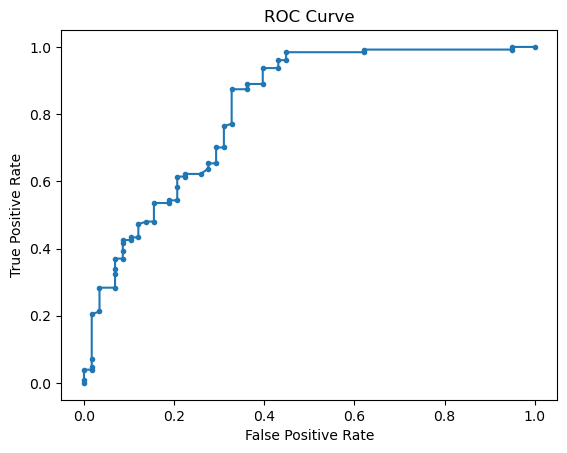

AUC Score: 0.82


In [28]:
y_prob = lr_l1.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc_score:.2f}")

### Logistic Regression with GridSearchCV.

In [ ]:
param_grid_lr = {
    'C': [0.1, 1, 10], 
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear'], 
    'max_iter': [1000]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(x_train, y_train)
best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(x_test)

train_acc_best_lr = accuracy_score(y_train, best_lr.predict(x_train))
test_acc_best_lr = accuracy_score(y_test, best_lr.predict(x_test))
auc_best_lr = roc_auc_score(y_test, best_lr.predict_proba(x_test)[:, 1])

print("Best LR - Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("Best Params:", grid_lr.best_params_)

Best LR - Test Accuracy: 0.8486486486486486
Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}


### Decision Tree

In [39]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

train_acc_dt = accuracy_score(y_train, dt.predict(x_train))
test_acc_dt = accuracy_score(y_test, dt.predict(x_test))
auc_dt = roc_auc_score(y_test, dt.predict_proba(x_test)[:, 1])

print("Decision Tree - Test Accuracy:", test_acc_dt)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree - Test Accuracy: 0.6972972972972973
[[38 20]
 [36 91]]
              precision    recall  f1-score   support

           0       0.51      0.66      0.58        58
           1       0.82      0.72      0.76       127

    accuracy                           0.70       185
   macro avg       0.67      0.69      0.67       185
weighted avg       0.72      0.70      0.71       185



### Decision Tree with GridSearchCV

In [46]:
params = {
    "criterion":("gini", "entropy"),
    "splitter":("best", "random"),
    "max_depth":(list(range(1, 20))),
    "min_samples_split":[2, 3, 4],
    "min_samples_leaf":list(range(1, 20)),
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), params, scoring="accuracy", n_jobs=-1, verbose=1, cv=3)
grid_dt.fit(x_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(x_test)

train_acc_best_dt = accuracy_score(y_train, best_dt.predict(x_train))
test_acc_best_dt = accuracy_score(y_test, best_dt.predict(x_test))
auc_best_dt = roc_auc_score(y_test, best_dt.predict_proba(x_test)[:, 1])

print("Decision Tree - Test Accuracy:", test_acc_best_dt)
print(f"Best paramters: {grid_dt.best_params_})")

Fitting 3 folds for each of 4332 candidates, totalling 12996 fits
Decision Tree - Test Accuracy: 0.8432432432432433
Best paramters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'})


## Models Comparison

In [43]:
results = pd.DataFrame({
    'Model': ['Logistic Regression L1', 'Logistic Regression L2', 'Best Logistic Regression', 'Decision Tree', 'Best Decision Tree'],
    'Train Acc': [train_acc_l1, train_acc_l2, train_acc_best_lr, train_acc_dt, train_acc_best_dt],
    'Test Acc': [test_acc_l1, test_acc_l2, test_acc_best_lr, test_acc_dt, test_acc_best_dt],
    'AUC': [auc_l1, auc_l2, auc_best_lr, auc_dt, auc_best_dt]
})
results

,Model,Train Acc,Test Acc,AUC
0,Logistic Regression L1,0.797203,0.848649,0.815164
1,Logistic Regression L2,0.797203,0.848649,0.818558
2,Best Logistic Regression,0.792541,0.848649,0.826093
3,Decision Tree,0.967366,0.697297,0.705064
4,Best Decision Tree,0.804196,0.843243,0.766630


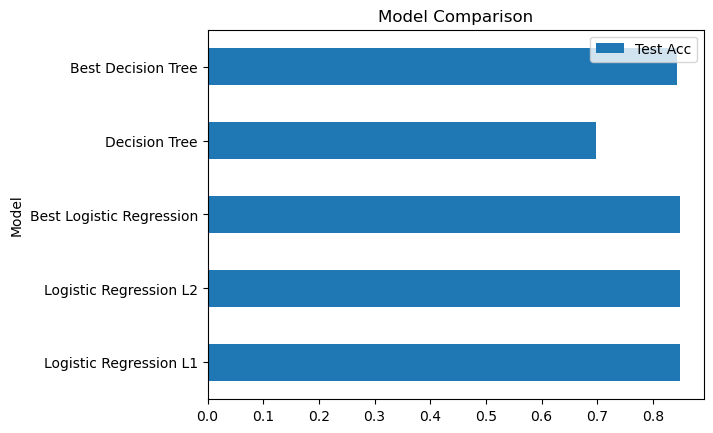

In [54]:
results.plot(x='Model', y='Test Acc', kind='barh')
plt.title('Model Comparison')
plt.show()

results = results.round(4)